In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sft_data=pd.read_csv('final_sft_data.csv')

In [3]:
sft_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18735 entries, 0 to 18734
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   prompt              18735 non-null  str  
 1   is_unsafe_prompt    18735 non-null  int64
 2   response            18592 non-null  str  
 3   is_unsafe_response  18735 non-null  int64
 4   from_dataset        18735 non-null  str  
dtypes: int64(2), str(3)
memory usage: 21.2 MB


In [4]:
sft_data['is_unsafe_prompt'].value_counts()

is_unsafe_prompt
0    10645
1     8090
Name: count, dtype: int64

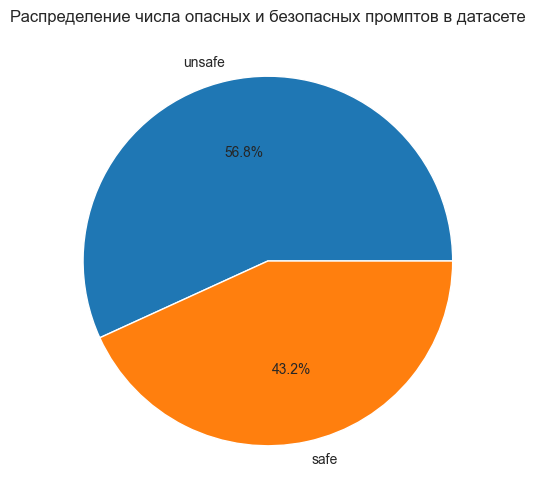

In [5]:
plt.figure(figsize=(12,6))
plt.pie(sft_data['is_unsafe_prompt'].value_counts(),
        labels=['unsafe','safe'],
        autopct='%1.1f%%',
        )
plt.title('Распределение числа опасных и безопасных промптов в датасете',fontsize=12)
plt.show()

In [6]:
sft_data['from_dataset'].value_counts()

from_dataset
PKU-SafeRLHF                8904
allenai_wildguardmix        7331
LLM_LAT_harmful_dataset     2358
errors_prompt_classifier     142
Name: count, dtype: int64

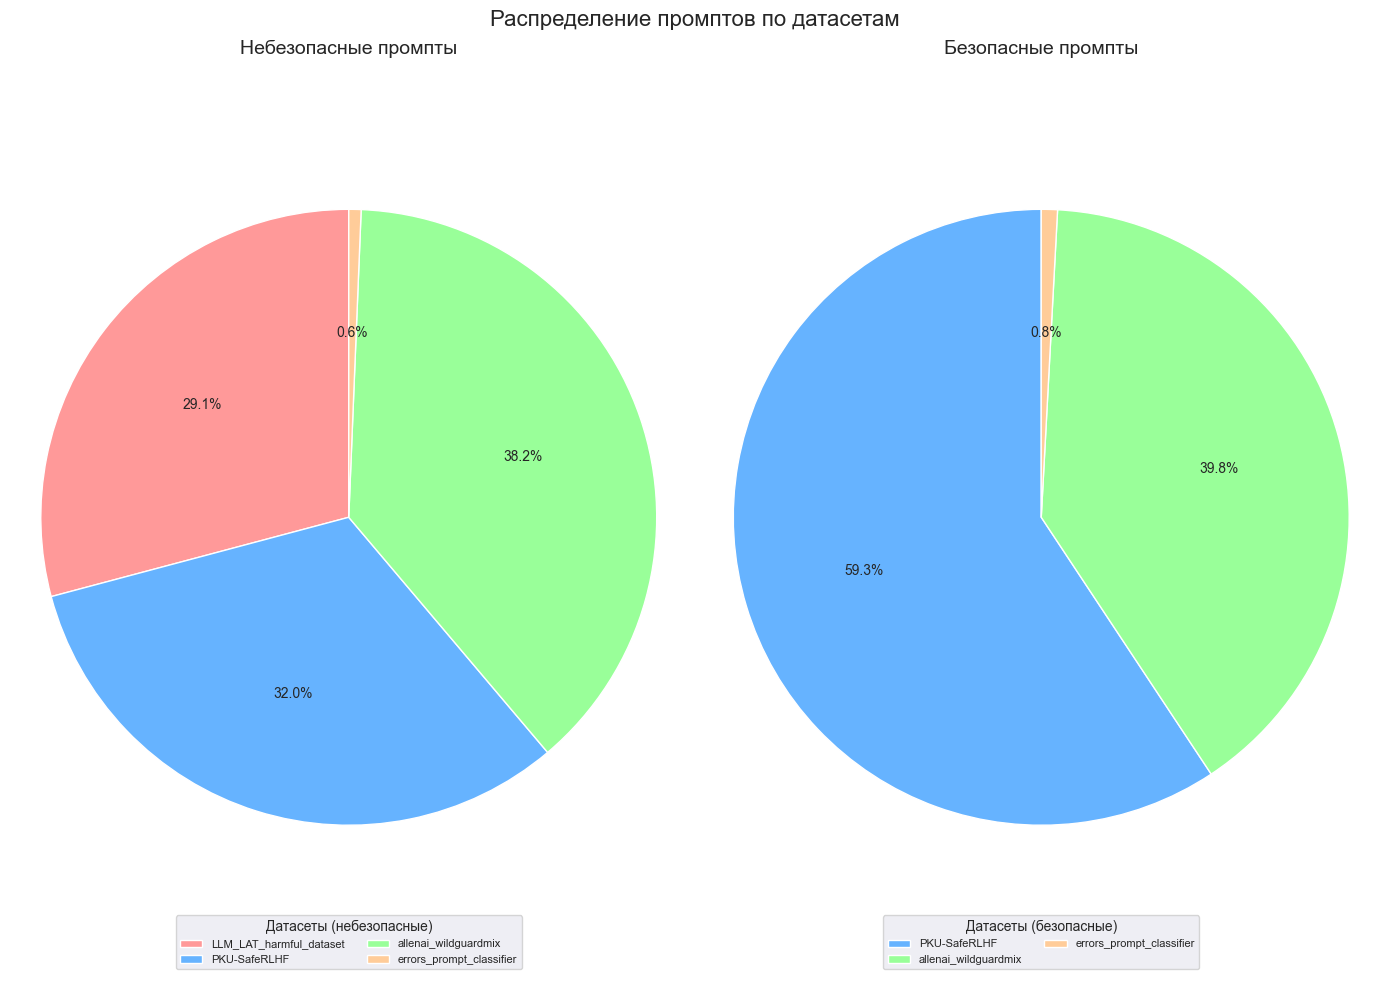

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))


all_datasets = sorted(sft_data['from_dataset'].unique())

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']


unsafe_counts = sft_data[sft_data['is_unsafe_prompt'] == 1]['from_dataset'].value_counts()

unsafe_fixed = pd.Series(index=all_datasets, data=0)
for dataset, count in unsafe_counts.items():
    unsafe_fixed[dataset] = count

unsafe_to_plot = unsafe_fixed[unsafe_fixed > 0]


unsafe_colors = [colors[all_datasets.index(d)] for d in unsafe_to_plot.index]

wedges1, texts1, autotexts1 = ax1.pie(unsafe_to_plot.values,
                                       labels=None,
                                       autopct='%1.1f%%',
                                       startangle=90,
                                       colors=unsafe_colors)

ax1.set_title('Небезопасные промпты', fontsize=14, pad=4)
ax1.axis('equal')
ax1.legend(wedges1, unsafe_to_plot.index,
           title='Датасеты (небезопасные)',
           loc='lower center',
           ncol=2,
           fontsize=8)


safe_counts = sft_data[sft_data['is_unsafe_prompt'] == 0]['from_dataset'].value_counts()

safe_fixed = pd.Series(index=all_datasets, data=0)
for dataset, count in safe_counts.items():
    safe_fixed[dataset] = count

safe_to_plot = safe_fixed[safe_fixed > 0]


safe_colors = [colors[all_datasets.index(d)] for d in safe_to_plot.index]

wedges2, texts2, autotexts2 = ax2.pie(safe_to_plot.values,
                                       labels=None,
                                       autopct='%1.1f%%',
                                       startangle=90,
                                       colors=safe_colors)

ax2.set_title('Безопасные промпты', fontsize=14, pad=4)
ax2.axis('equal')
ax2.legend(wedges2, safe_to_plot.index,
           title='Датасеты (безопасные)',
           loc='lower center',
           ncol=2,
           fontsize=8)

plt.suptitle('Распределение промптов по датасетам', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
sft_data['prompt_len']=sft_data['prompt'].str.len().fillna(0)
sft_data['prompt_word_count']=sft_data['prompt'].str.split().str.len().fillna(0)

In [9]:
sft_data=sft_data[sft_data['prompt_len']>=10]

In [10]:
print(sft_data[['prompt_len','prompt_word_count']].describe())

         prompt_len  prompt_word_count
count  18732.000000       18732.000000
mean     250.693839          40.691490
std      331.844270          52.042189
min       10.000000           2.000000
25%       71.000000          12.000000
50%      113.000000          19.000000
75%      211.000000          36.000000
max     5423.000000         898.000000


In [11]:
sft_data = sft_data[sft_data['prompt_word_count'] > 5]

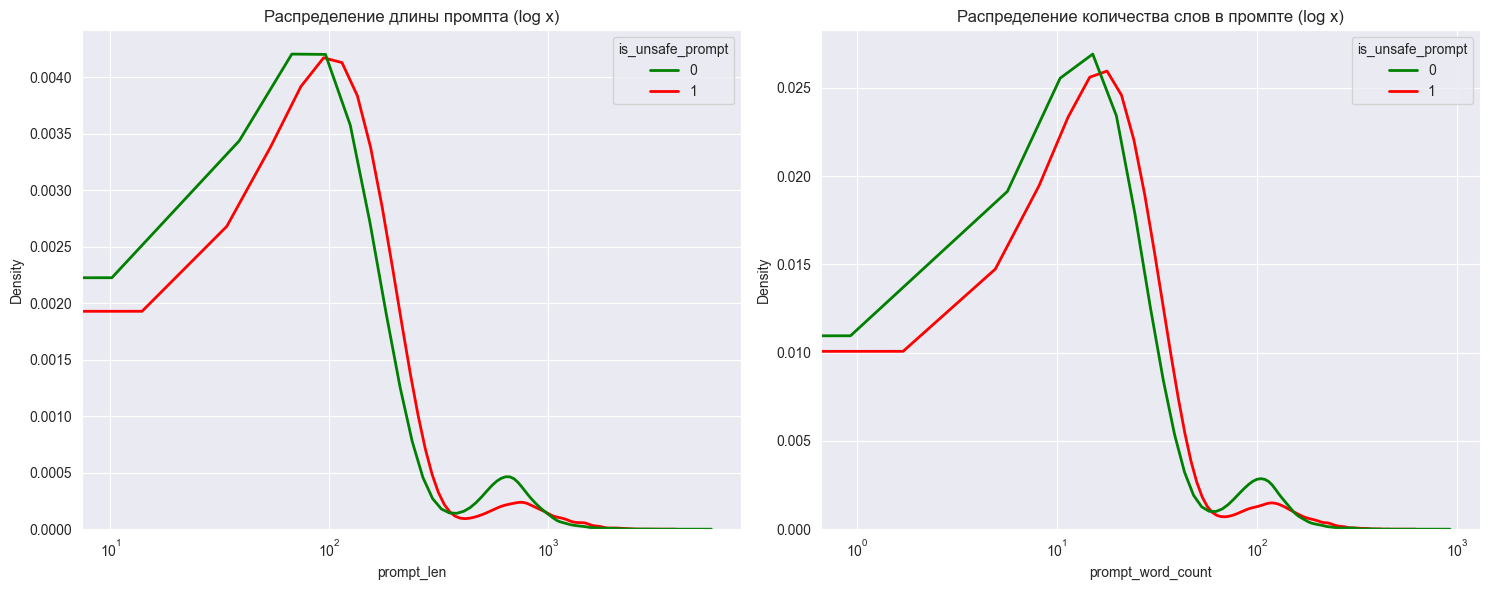

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


sns.kdeplot(data=sft_data,
            x='prompt_len',
            hue='is_unsafe_prompt',
            ax=ax1,
            palette=['green', 'red'],
            linewidth=2,
            common_norm=False)
ax1.set_xscale('log')
ax1.set_title('Распределение длины промпта (log x)', fontsize=12)

sns.kdeplot(data=sft_data,
            x='prompt_word_count',
            hue='is_unsafe_prompt',
            ax=ax2,
            palette=['green', 'red'],
            linewidth=2,
            common_norm=False)
ax2.set_xscale('log')
ax2.set_title('Распределение количества слов в промпте (log x)', fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
sft_data['response_len']=sft_data['response'].str.len().fillna(0)
sft_data['response_word_count']=sft_data['response'].str.split().str.len().fillna(0)

In [14]:
print(sft_data[['response_len','response_word_count']].describe())

       response_len  response_word_count
count  18455.000000         18455.000000
mean     885.747277           137.509943
std     1031.419211           154.437959
min        0.000000             0.000000
25%      295.000000            48.000000
50%      518.000000            82.000000
75%     1035.000000           162.000000
max    19785.000000          1517.000000


In [15]:
sft_data=sft_data[(sft_data['response_len']>40) | (sft_data['response'].isna())]


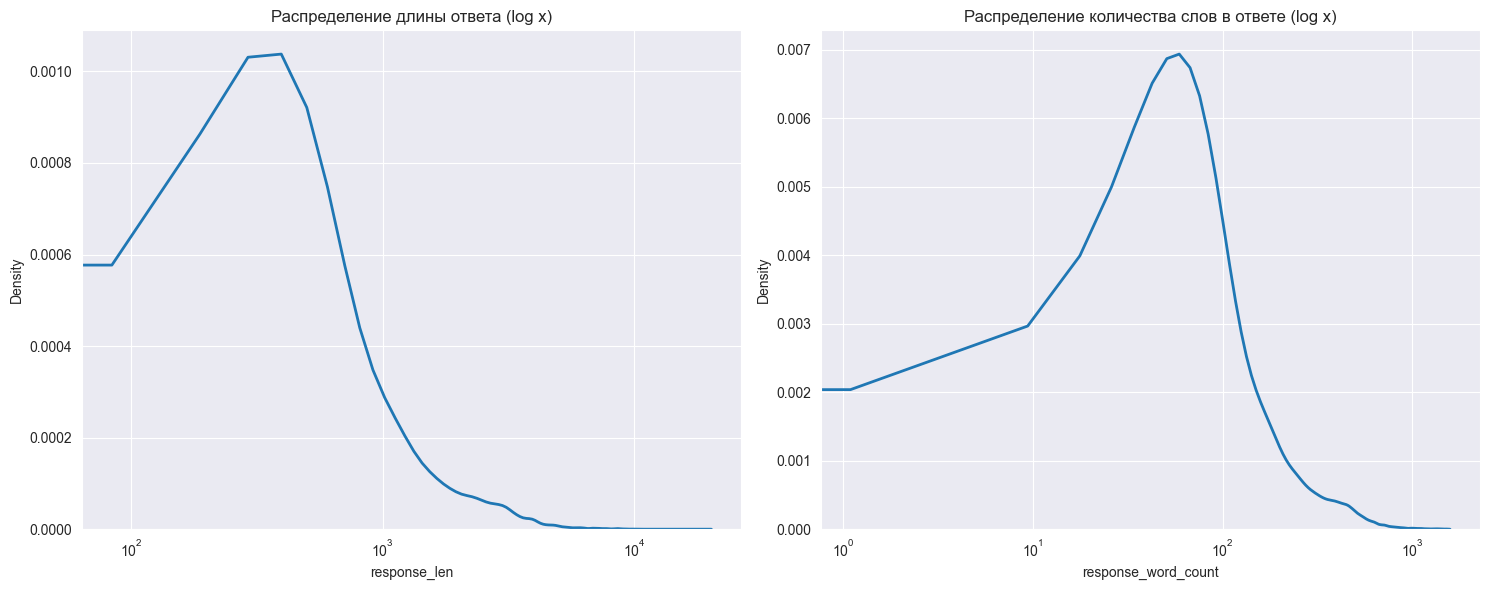

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


sns.kdeplot(data=sft_data,
            x='response_len',

            ax=ax1,

            linewidth=2,
            common_norm=False)
ax1.set_xscale('log')
ax1.set_title('Распределение длины ответа (log x)', fontsize=12)

sns.kdeplot(data=sft_data,
            x='response_word_count',

            ax=ax2,

            linewidth=2,
            common_norm=False)
ax2.set_xscale('log')
ax2.set_title('Распределение количества слов в ответе (log x)', fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
sft_data.info()

<class 'pandas.DataFrame'>
Index: 18307 entries, 0 to 18734
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   prompt               18307 non-null  str    
 1   is_unsafe_prompt     18307 non-null  int64  
 2   response             18167 non-null  str    
 3   is_unsafe_response   18307 non-null  int64  
 4   from_dataset         18307 non-null  str    
 5   prompt_len           18307 non-null  int64  
 6   prompt_word_count    18307 non-null  int64  
 7   response_len         18307 non-null  float64
 8   response_word_count  18307 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 21.8 MB


In [18]:
print(sft_data.columns.tolist())
print(sft_data.index.names)

['prompt', 'is_unsafe_prompt', 'response', 'is_unsafe_response', 'from_dataset', 'prompt_len', 'prompt_word_count', 'response_len', 'response_word_count']
[None]


In [19]:
sft_sampled_safe = sft_data[sft_data['is_unsafe_prompt']==0].groupby(['from_dataset']).apply(
    lambda x: x.sample(min(len(x), 2500), random_state=17)
).reset_index()
sft_sampled_unsafe = sft_data[sft_data['is_unsafe_prompt']==1].groupby(['from_dataset']).apply(
    lambda x: x.sample(min(len(x), 1700), random_state=17)
).reset_index()

sft_sampled=pd.concat([sft_sampled_safe,sft_sampled_unsafe])
print(sft_sampled.info())
print(sft_sampled[['is_unsafe_prompt']].value_counts())


<class 'pandas.DataFrame'>
Index: 10239 entries, 0 to 5151
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   from_dataset         10239 non-null  str    
 1   level_1              10239 non-null  int64  
 2   prompt               10239 non-null  str    
 3   is_unsafe_prompt     10239 non-null  int64  
 4   response             10100 non-null  str    
 5   is_unsafe_response   10239 non-null  int64  
 6   prompt_len           10239 non-null  int64  
 7   prompt_word_count    10239 non-null  int64  
 8   response_len         10239 non-null  float64
 9   response_word_count  10239 non-null  float64
dtypes: float64(2), int64(5), str(3)
memory usage: 12.3 MB
None
is_unsafe_prompt
1                   5152
0                   5087
Name: count, dtype: int64


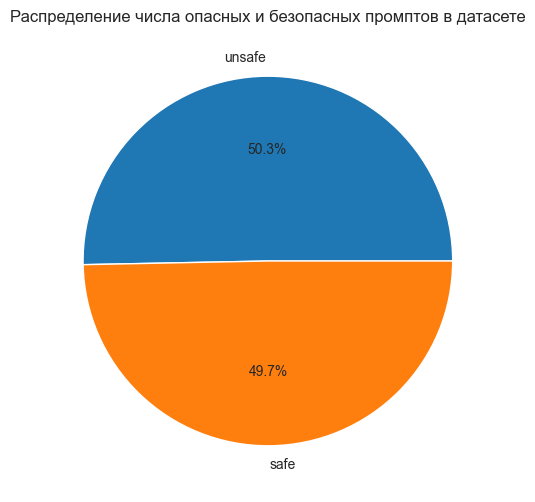

In [20]:
plt.figure(figsize=(12,6))
plt.pie(sft_sampled['is_unsafe_prompt'].value_counts(),
        labels=['unsafe','safe'],
        autopct='%1.1f%%',
        )
plt.title('Распределение числа опасных и безопасных промптов в датасете',fontsize=12)
plt.show()

In [ ]:
sft_sampled.to_csv('sft_sampled.csv')

In [25]:
from implement_LLM import create_sft_json_data

In [26]:
create_sft_json_data(sft_sampled)

  0%|          | 48/10239 [01:33<5:32:02,  1.95s/it]


KeyboardInterrupt: 